# Imports and constants

In [11]:
import numpy as np
from numpy.linalg import norm as norm
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from numba import njit

plt.rcParams.update({'font.size':13})

# CONSTANTS
RADIUS = 6378 # m
MAGNETIC_FIELD = 3.11e-5 # T

ELEMENTARY_CHARGE = 1.602e-19 # C

ENERGY_ELECTRON = 100e3 * 1.602e-19 # J
MASS_ELECTRON = 9.109e-31 # kg
ENERGY_PROTON = 100 * 1.602e-19 # J
MASS_PROTON = 1.673e-27 # kg

# COMPUTE GYRATION PERIOD TO FIND TIME OPTIMAL TIME STEP VALUE (L=4)
GYRO_FREQUENCY_ELECTRON = ELEMENTARY_CHARGE*MAGNETIC_FIELD/(4**3)/MASS_ELECTRON
GYRO_FREQUENCY_PROTON = ELEMENTARY_CHARGE*MAGNETIC_FIELD/(4**3)/MASS_PROTON

# Electron

## Trajectory

In [29]:
STEPS = 64500
dt = 1e-7
ELECTRIC_FIELD = 11.224 # V/m

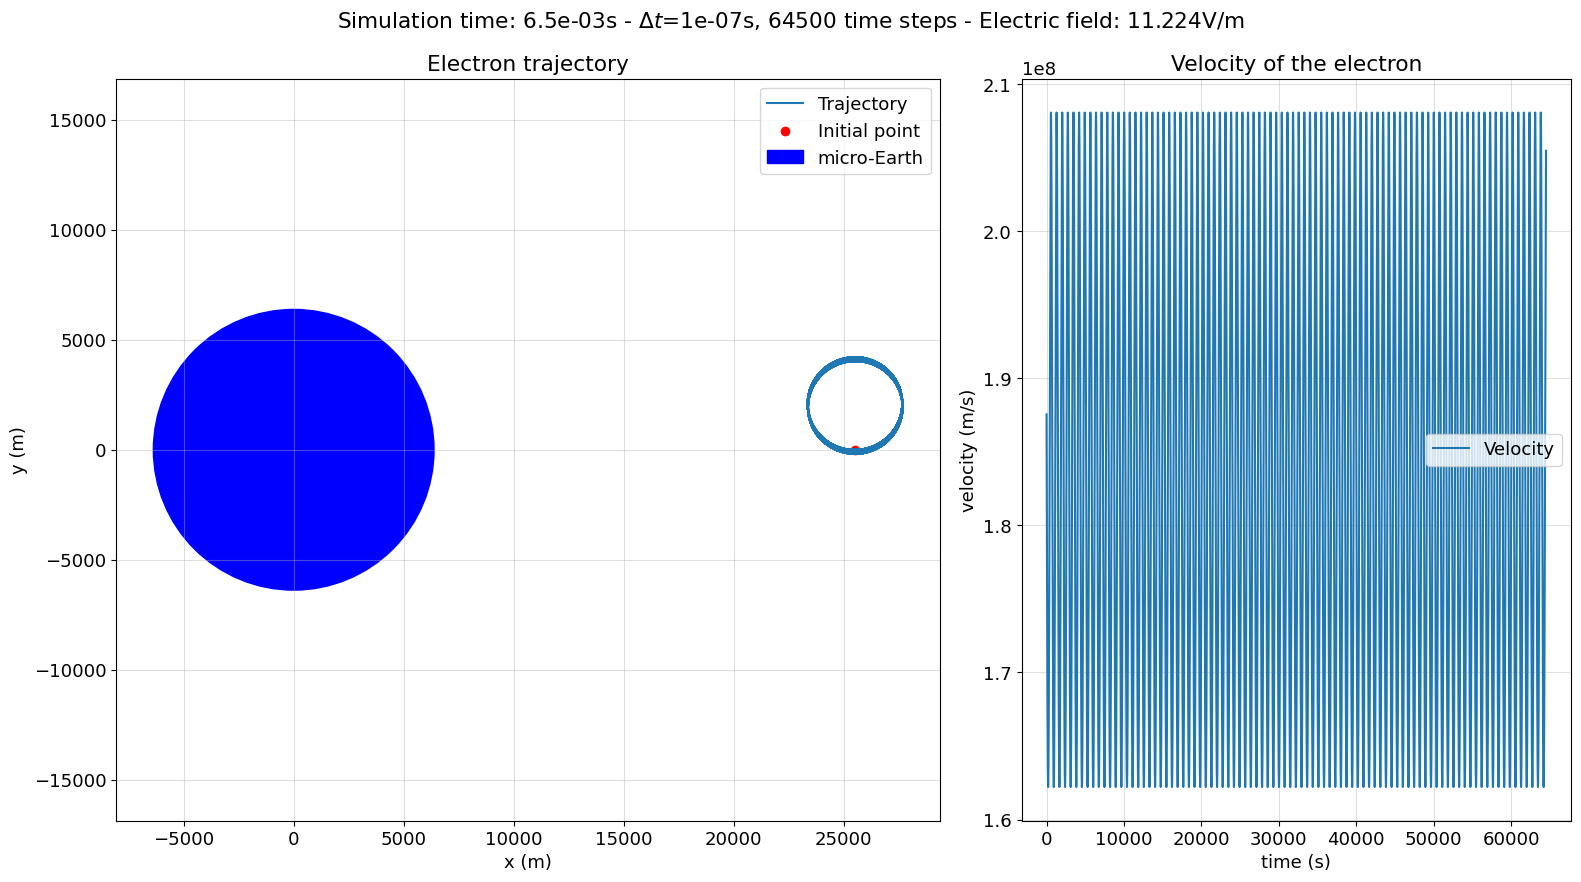

In [30]:
# CONSTANTS FOR INTEGRATION
C_ELECTRON = - dt * ELEMENTARY_CHARGE / MASS_ELECTRON * 0.5

@njit
def update_ELECTRON(e):

    # POSITION ARRAYS (AT t=0, L=4)
    r_ELECTRON = np.empty((STEPS, 3))
    r_ELECTRON[0] = np.array([4*RADIUS, 0, 0])

    # VELOCITY ARRAYS (AT t=0, VELOCITY IS RADIAL)
    v_ELECTRON = np.empty((STEPS, 3))
    v_ELECTRON[0] = np.array([np.sqrt(2*ENERGY_ELECTRON/MASS_ELECTRON), 0, 0])

    for step in range(1, STEPS):
        
        r = r_ELECTRON[step-1]
        v = v_ELECTRON[step-1]

        b_field = MAGNETIC_FIELD * (RADIUS/norm(r))**3 * np.array([0, 0, 1])
        e_field = e * r / norm(r)

        # BORIS ALGORITHM
        u = v + C_ELECTRON * e_field
        h = C_ELECTRON * b_field
        s = 2*h / (1+norm(h)**2)
        u2 = u + np.cross(u + np.cross(u, h), s)

        v_ELECTRON[step] = u2 + C_ELECTRON * e_field
        r_ELECTRON[step] = r + dt*v_ELECTRON[step]

    return r_ELECTRON[:, :2], v_ELECTRON[:, :2]

r_ELECTRON, v_ELECTRON = update_ELECTRON(ELECTRIC_FIELD)

fig, axs = plt.subplots(1, 2, figsize=(16, 9), gridspec_kw={'width_ratios':[0.6, 0.4]})
axs[0].plot(r_ELECTRON[1:, 0], r_ELECTRON[1:, 1], label='Trajectory')
axs[0].scatter(r_ELECTRON[0, 0], r_ELECTRON[0, 1], color='red', label='Initial point')
axs[0].add_patch(Circle((0, 0), RADIUS, color='blue', label='micro-Earth'))
axs[0].autoscale_view()
axs[0].set_title('Electron trajectory')
axs[0].set_xlabel('x (m)')
axs[0].set_ylabel('y (m)')
axs[0].legend()
axs[0].grid(alpha=.4)
axs[0].axis('equal')

axs[1].plot(range(STEPS), norm(v_ELECTRON, axis=1), label='Velocity')
if ELECTRIC_FIELD ==0: axs[1].axhline(norm(v_ELECTRON[0]), label='Expected velocity\n' rf'$v_0$={norm(v_ELECTRON[0]):.1e}m/s', c='tab:orange', alpha=.7)
# axs[1].axhline(3.0e8, label='Speed of light', c='red', alpha=.7)
if np.max(norm(v_ELECTRON, axis=1)) > 3.0e8:
    axs[1].fill_between(range(STEPS), 3.0e8, axs[1].get_ylim()[1], alpha=.2, color='red')
axs[1].set_xlabel('time (s)')
axs[1].set_ylabel('velocity (m/s)')
axs[1].legend()
axs[1].grid(alpha=.4)
axs[1].set_title('Velocity of the electron')
if ELECTRIC_FIELD==0: axs[1].set_ylim(np.min(norm(v_ELECTRON, axis=1)), np.max(norm(v_ELECTRON, axis=1)))

fig.suptitle(rf'Simulation time: {STEPS*dt:.1e}s - $\Delta t$={dt}s, {STEPS} time steps - Electric field: {ELECTRIC_FIELD}V/m')
fig.tight_layout()
plt.show()

In [26]:
drift = []
e_linspace = np.linspace(10, 13, 50)
for e in e_linspace:
    r_ELECTRON, v_ELECTRON = update_ELECTRON(e)
    drift.append(np.unwrap(np.arctan2(r_ELECTRON[:, 1], r_ELECTRON[:, 0])).std())

In [27]:
e_linspace[np.argmin(np.abs(drift))]

np.float64(11.224489795918368)

In [31]:
vDrift_ELECTRON_A = -6*4**2*ENERGY_ELECTRON/ELEMENTARY_CHARGE/MAGNETIC_FIELD/RADIUS*0.5
ELECTRIC_FIELD_A = - MAGNETIC_FIELD/4**3 * vDrift_ELECTRON_A
print(ELECTRIC_FIELD_A)
print(abs((ELECTRIC_FIELD_A-ELECTRIC_FIELD)/ELECTRIC_FIELD_A)*100)

11.75917215428034
4.551104000000002


## Drift velocity

In [15]:
phi_ELECTRON = -np.unwrap(np.arctan2(r_ELECTRON[:, 1], r_ELECTRON[:, 0]))
vDrift_ELECTRON = norm(r_ELECTRON, axis=1).mean() * np.polyfit(np.linspace(0, STEPS*dt, STEPS), phi_ELECTRON, 1)[0]
print(f'{vDrift_ELECTRON:.2e}')

-2.50e+07


In [16]:
print(f'{vDrift_ELECTRON_A:.4e}')

-2.4199e+07


In [17]:
print(f'{abs((vDrift_ELECTRON_A - vDrift_ELECTRON)/vDrift_ELECTRON_A)*100:.2f}%')

3.30%


# Proton

## Trajectory

In [36]:
STEPS = 63500
dt = 1e-4
ELECTRIC_FIELD = -0.01080 # V/m

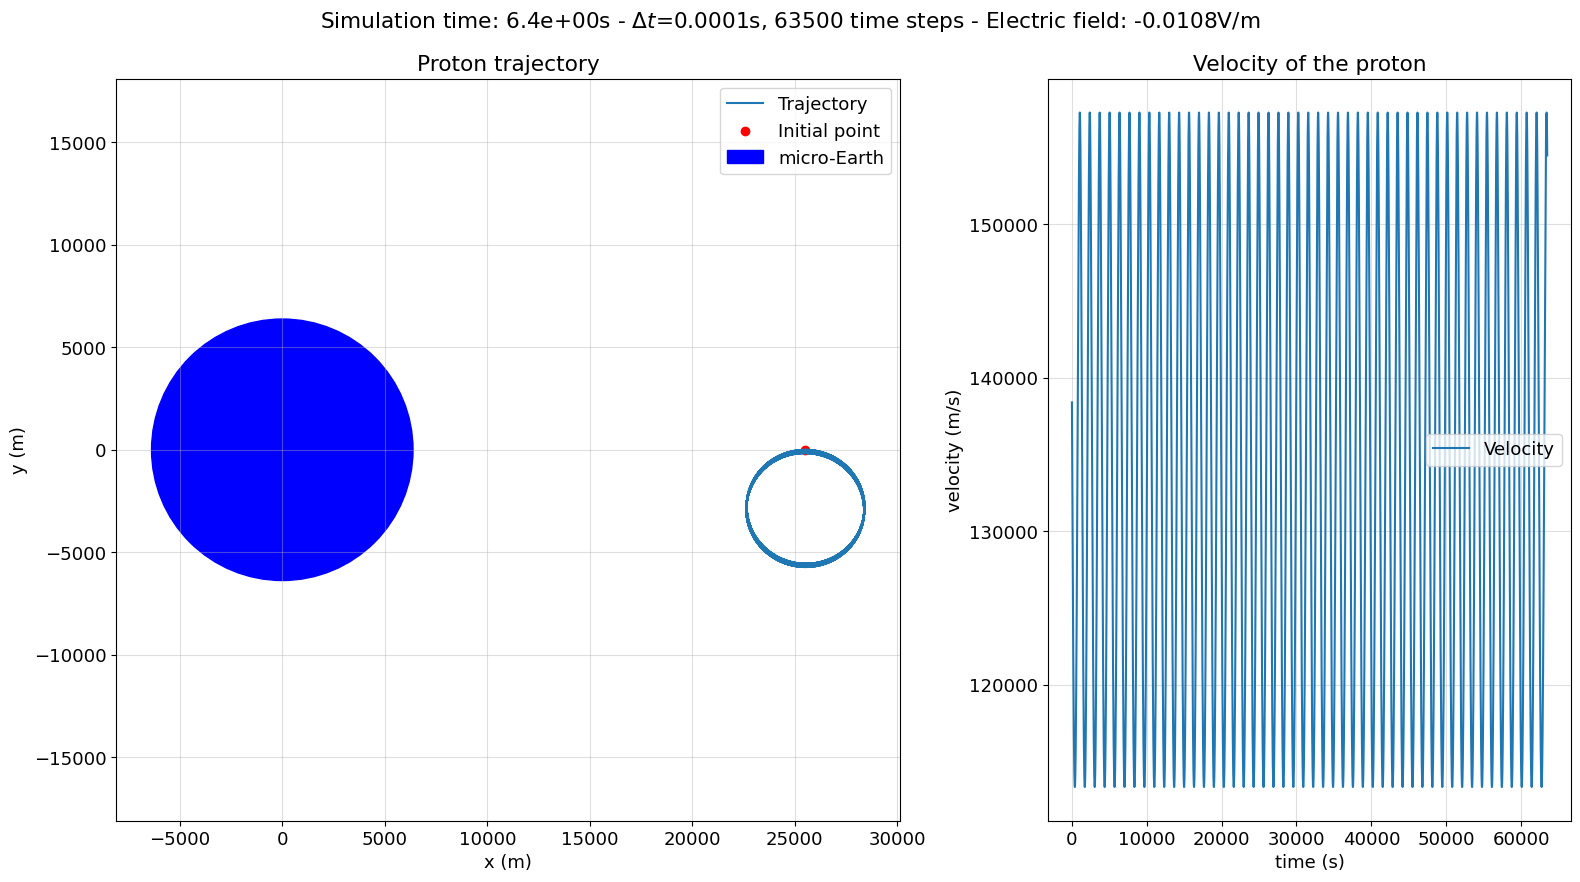

In [37]:
# CONSTANTS FOR INTEGRATION
C_PROTON = dt * ELEMENTARY_CHARGE / MASS_PROTON * 0.5

@njit
def update_PROTON(e):

    # POSITION ARRAYS (AT t=0, L=4)
    r_PROTON = np.empty((STEPS, 3))
    r_PROTON[0] = np.array([4*RADIUS, 0, 0])

    # VELOCITY ARRAYS (AT t=0, VELOCITY IS RADIAL)
    v_PROTON = np.empty((STEPS, 3))
    v_PROTON[0] = np.array([np.sqrt(2*ENERGY_PROTON/MASS_PROTON), 0, 0])

    for step in range(1, STEPS):
        
        r = r_PROTON[step-1]
        v = v_PROTON[step-1]

        b_field = MAGNETIC_FIELD * (RADIUS/norm(r))**3 * np.array([0, 0, 1])
        e_field = e * r / norm(r)

        # BORIS ALGORITHM
        u = v + C_PROTON * e_field
        h = C_PROTON * b_field
        s = 2*h / (1+norm(h)**2)
        u2 = u + np.cross(u + np.cross(u, h), s)

        v_PROTON[step] = u2 + C_PROTON * e_field
        r_PROTON[step] = r + dt*v_PROTON[step]

    return r_PROTON[:, :2], v_PROTON[:, :2]

r_PROTON, v_PROTON = update_PROTON(ELECTRIC_FIELD)

fig, axs = plt.subplots(1, 2, figsize=(16, 9), gridspec_kw={'width_ratios':[0.6, 0.4]})
axs[0].plot(r_PROTON[1:, 0], r_PROTON[1:, 1], label='Trajectory')
axs[0].scatter(r_PROTON[0, 0], r_PROTON[0, 1], color='red', label='Initial point')
axs[0].add_patch(Circle((0, 0), RADIUS, color='blue', label='micro-Earth'))
axs[0].autoscale_view()
axs[0].set_title('Proton trajectory')
axs[0].set_xlabel('x (m)')
axs[0].set_ylabel('y (m)')
axs[0].legend()
axs[0].grid(alpha=.4)
axs[0].axis('equal')

axs[1].plot(range(STEPS), norm(v_PROTON, axis=1), label='Velocity')
if ELECTRIC_FIELD ==0: axs[1].axhline(norm(v_PROTON[0]), label='Expected velocity\n' rf'$v_0$={norm(v_PROTON[0]):.1e}m/s', c='tab:orange', alpha=.7)
# axs[1].axhline(3.0e8, label='Speed of light', c='red', alpha=.7)
if np.max(norm(v_PROTON, axis=1)) > 3.0e8:
    axs[1].fill_between(range(STEPS), 3.0e8, axs[1].get_ylim()[1], alpha=.2, color='red')
axs[1].set_xlabel('time (s)')
axs[1].set_ylabel('velocity (m/s)')
axs[1].legend()
axs[1].grid(alpha=.4)
axs[1].set_title('Velocity of the proton')
if ELECTRIC_FIELD==0: axs[1].set_ylim(np.min(norm(v_PROTON, axis=1)), np.max(norm(v_PROTON, axis=1)))

fig.suptitle(rf'Simulation time: {STEPS*dt:.1e}s - $\Delta t$={dt}s, {STEPS} time steps - Electric field: {ELECTRIC_FIELD}V/m')
fig.tight_layout()
plt.show()

In [34]:
drift = []
e_linspace = np.linspace(-0.009, -0.013, num=50)
for e in e_linspace:
    r_PROTON, v_PROTON = update_PROTON(e)
    drift.append(np.unwrap(np.arctan2(r_PROTON[:, 1], r_PROTON[:, 0])).std())

In [35]:
e_linspace[np.argmin(np.abs(drift))]

np.float64(-0.010795918367346937)

In [38]:
vDrift_PROTON_A = 6*4**2*ENERGY_PROTON/ELEMENTARY_CHARGE/MAGNETIC_FIELD/RADIUS*0.5
ELECTRIC_FIELD_A = -MAGNETIC_FIELD/4**3 * vDrift_PROTON_A
print(ELECTRIC_FIELD_A)
print(abs((ELECTRIC_FIELD_A-ELECTRIC_FIELD)/ELECTRIC_FIELD_A)*100)

-0.011759172154280339
8.156799999999995


## Drift velocity

In [21]:
phi_PROTON = -np.unwrap(np.arctan2(r_PROTON[:, 1], r_PROTON[:, 0]))
vDrift_PROTON = norm(r_PROTON, axis=1).mean() * np.polyfit(np.linspace(0, STEPS*dt, STEPS), phi_PROTON, 1)[0]
print(f'{vDrift_PROTON:.2e}')

2.58e+04


In [22]:
print(f'{vDrift_PROTON_A:.4e}')

2.4199e+04


In [23]:
print(f'{abs((vDrift_PROTON_A - vDrift_PROTON)/vDrift_PROTON_A)*100:.2f}%')

6.47%
